<a href="https://colab.research.google.com/github/Muzzikon/WWML/blob/main/WWML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
import seaborn as sns

# The first 3 week

In [6]:
def generate_apartment():
    location = random.randint(1, 10)
    rooms = random.randint(1, 6)
    distance = round(random.uniform(0.5, 25), 2)
    floor = random.randint(1, 25)

    mean_area = 50  # Средняя площадь
    std_area = 20   # Стандартное отклонение площади
    S = round(np.random.normal(mean_area, std_area), 1)
    S = max(S, 10)  # Площадь не может быть меньше 10 м^2

    base_m2_price = 150000
    loc_coeff = 1.7 - (location / 10)
    dist_coeff = max(0.6, 1 - (distance / 50))
    final_m2_price = base_m2_price * loc_coeff * dist_coeff

    total_price = (int((S * final_m2_price) * random.uniform(0.95, 1.05)) // 10000) * 10000
    total_vis_price = str(total_price)[:-6] + '.' + str(total_price)[-6:-3] + '.' + str(total_price)[-4:-1]
    information = {
        "район": location,
        "площадь m^2": S,
        "кол-во комнат": rooms,
        "удаленность от центра (км)": distance,
        "этаж": floor,
        "цена": total_price}

    return information

In [7]:
apartments = [generate_apartment() for i in range(10001)]
data_set = pd.DataFrame(apartments)
pd.set_option('display.expand_frame_repr', False) # Запретить перенос строк
pd.set_option('display.max_columns', None)       # Показывать все столбцы
print (data_set)

       район  площадь m^2  кол-во комнат  удаленность от центра (км)  этаж     цена
0         10         50.7              2                       16.63    18  3390000
1          6         39.3              2                        9.43     5  5050000
2          3         25.0              4                       20.17    25  3060000
3          7         42.7              6                       12.95    11  4840000
4          1         45.9              3                        8.54    11  9370000
...      ...          ...            ...                         ...   ...      ...
9996       7         47.0              4                       13.93    20  5030000
9997       3         54.9              1                       21.99    18  7120000
9998       4         48.4              6                       13.58    10  6860000
9999       8         55.8              4                       12.64     5  5800000
10000      9         68.7              5                       20.61     1  

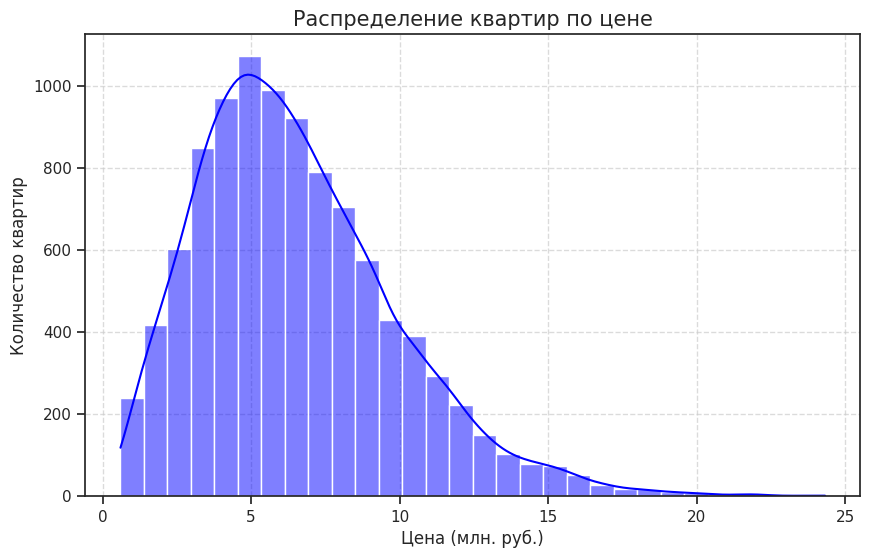

In [8]:
#Гистограмма
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="ticks", palette="pastel")
plt.figure(figsize=(10,6))
prices_in_millions = data_set["цена"] / 1_000_000
sns.histplot(prices_in_millions, bins=30, kde=True, color='blue')
plt.title("Распределение квартир по цене",fontsize=15)
plt.xlabel("Цена (млн. руб.)", fontsize=12)
plt.ylabel("Количество квартир", fontsize=12)
plt.ticklabel_format(style='plain', axis='x')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

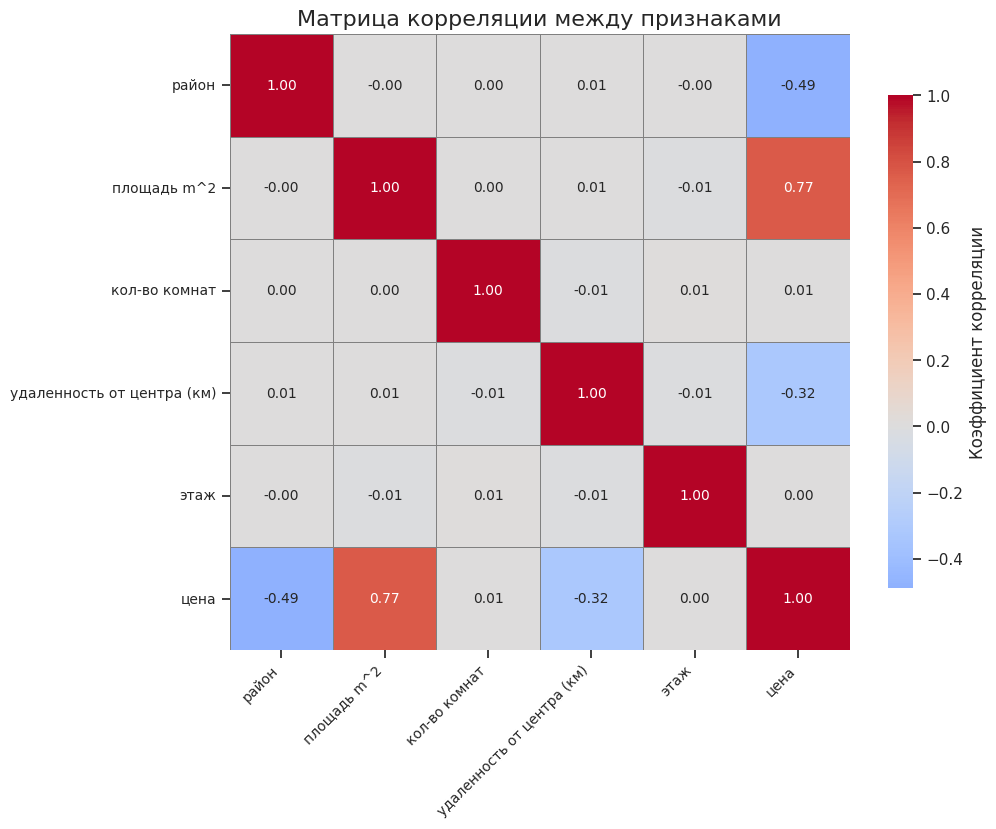

In [11]:
# Матрица корреляции
correlation_matrix = data_set.corr()

plt.figure(figsize=(10, 8))

sns.heatmap(correlation_matrix,
            annot=True,
            cmap='coolwarm',
            center=0,
            cbar_kws={"shrink": 0.8, "label": "Коэффициент корреляции"},
            fmt='.2f',
            annot_kws={'size': 10},

            linewidths=0.5,
            linecolor='gray')

plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)

plt.title("Матрица корреляции между признаками", fontsize=16)
plt.show()